In [1]:
import numpy as np
import pandas as pd

df=pd.read_csv('product_sales.csv')

In [2]:
# df.info()
df.describe()
# df.head()
# df.isna().sum()

,Price,QuantitySold
count,100.000000,100.00000
mean,48.576100,50.85000
std,20.207237,30.64801
min,3.640000,0.00000
25%,35.340000,23.00000
50%,46.925000,47.50000
75%,60.145000,80.25000
max,111.220000,99.00000


In [3]:
def convert_rating(rating) -> int | None:
    rating=str(rating).strip()
    if rating.isdigit():
        return int(rating)

    stars={'⭐', '★'}
    star_count=sum(1 for c in rating if c in stars)

    return star_count
    
df=df.drop(columns=['ProductID', 'Review'])
df['Rating']=df['Rating'].apply(convert_rating)
df['Price']=df['Price'].round(2)

In [4]:
Q3=60.145
Q1=35.34
IQR=Q3-Q1

lower_bound=round(Q1-1.5*IQR)
upper_bound=round(Q3+1.5*IQR)

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

Lower Bound: -2
Upper Bound: 97


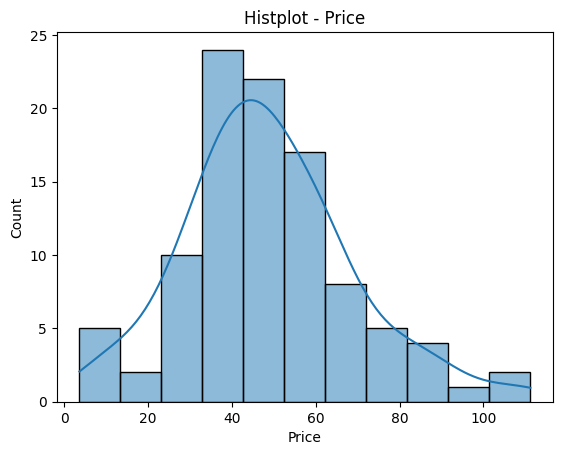

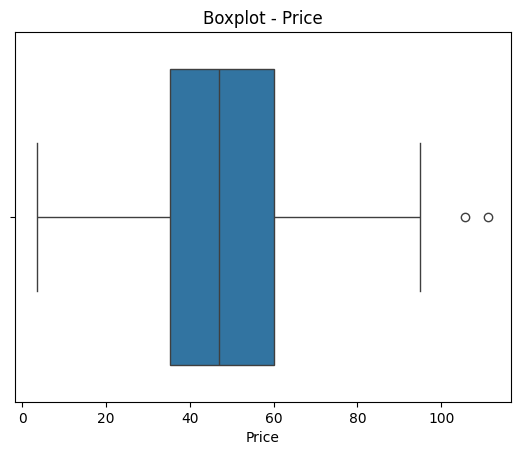

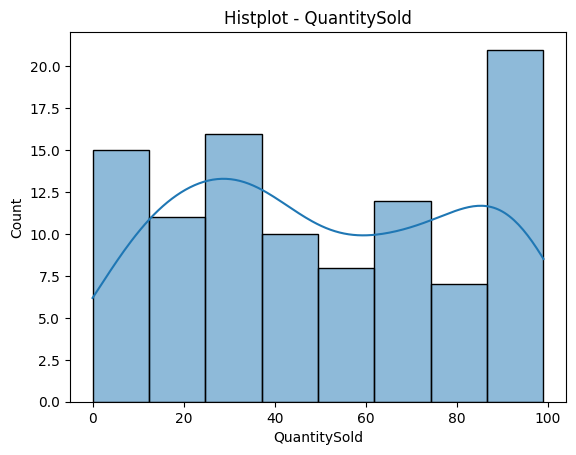

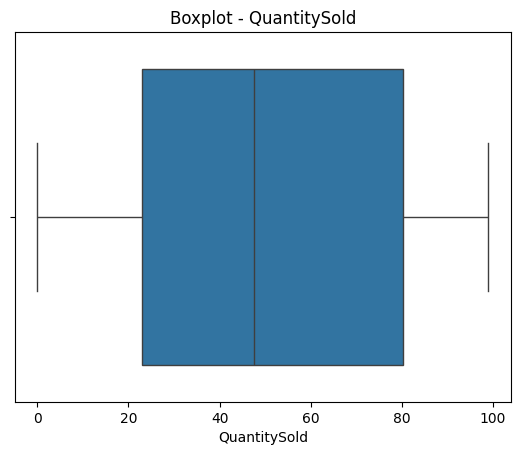

In [5]:
''' [4] Visualize Numeric Variables '''
import seaborn as sns
import matplotlib.pyplot as plt

cols=['Price', 'QuantitySold']

for col in cols:
    sns.histplot(df[col], kde=True)
    plt.title(f'Histplot - {col}')
    plt.show()
    
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()

In [6]:
outliers=df[df['Price'] > upper_bound]
print(outliers['Price'])

df['Price_capped']=df['Price'].clip(upper=upper_bound)

13    111.22
26    105.68
Name: Price, dtype: float64


In [7]:
from scipy.stats import skew

skewness_price=skew(df['Price'])
skewness_quantity_sold=skew(df['QuantitySold'])
print(f"Skewness(Price): {skewness_price}")
print(f"Skewness(QuantitySold): {skewness_quantity_sold}")

Skewness(Price): 0.5177307163032288
Skewness(QuantitySold): 0.06307206184888946


Brand (Unique: 6):
Brand
Soylent     25
Globex      19
Initech     17
Hooli       17
Umbrella    11
Acme        11
Name: count, dtype: int64



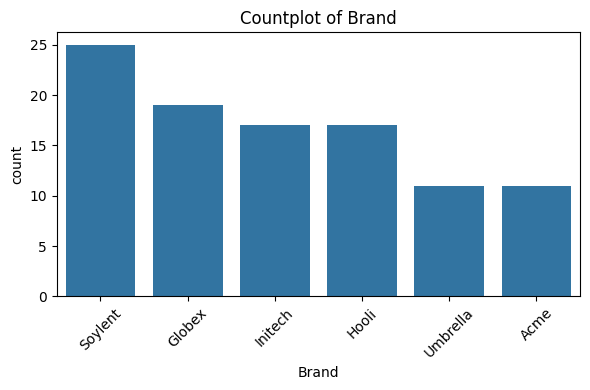

ProductType (Unique: 6):
ProductType
Electronics    22
Food           21
Furniture      17
Toys           15
Books          15
Clothing       10
Name: count, dtype: int64



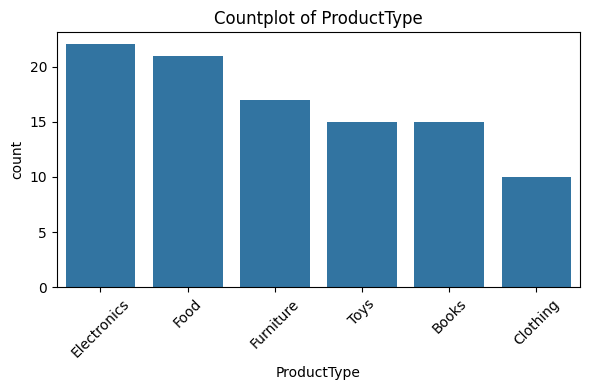

StoreLocation (Unique: 6):
StoreLocation
New York       24
Houston        22
Chicago        20
Miami          14
Los Angeles    13
Phoenix         7
Name: count, dtype: int64



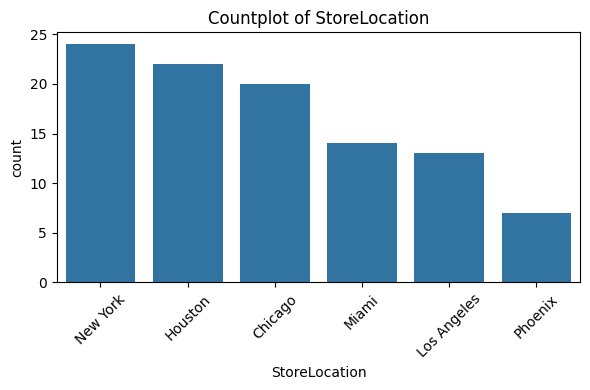

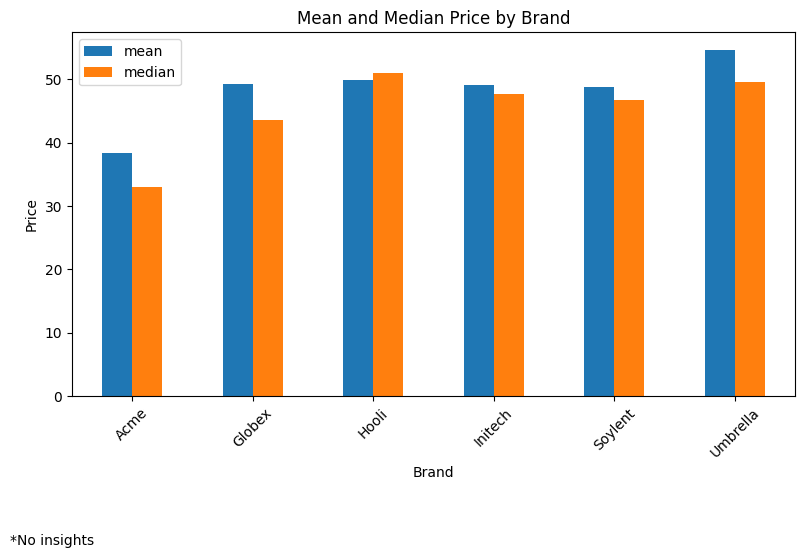

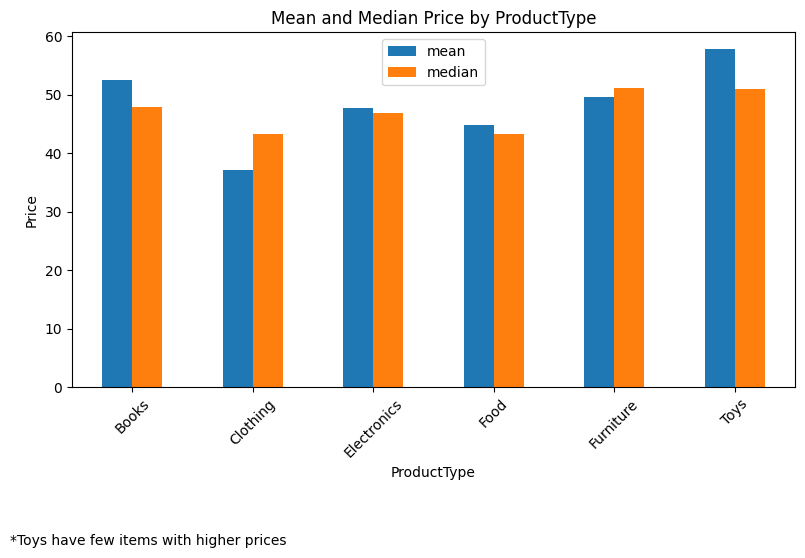

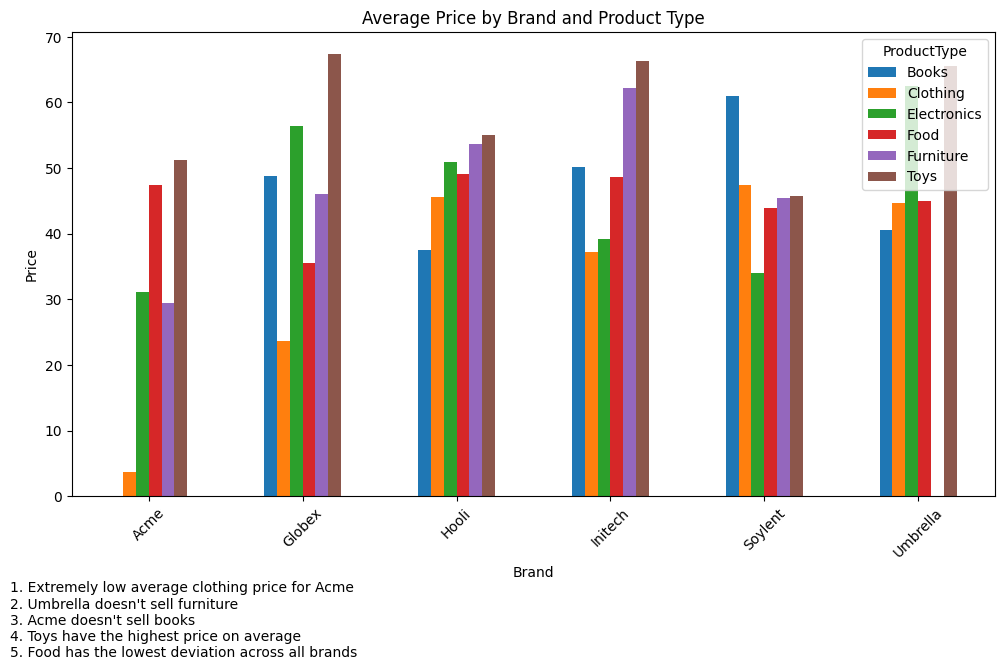

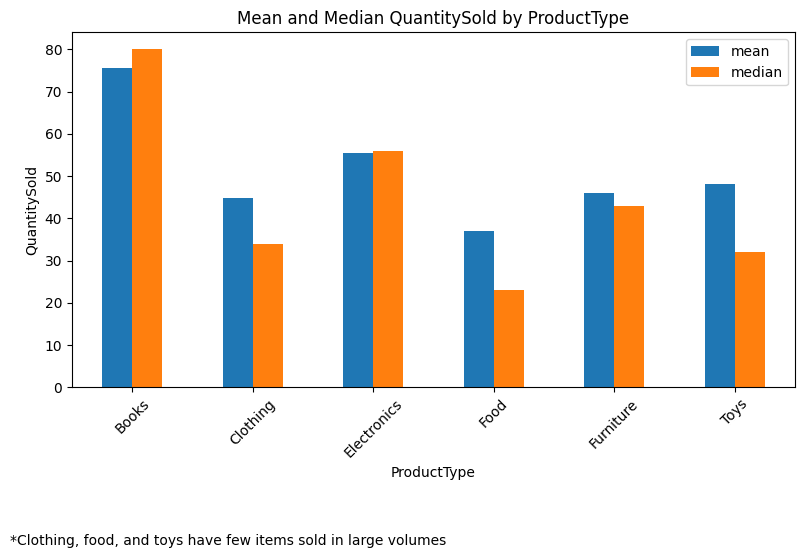

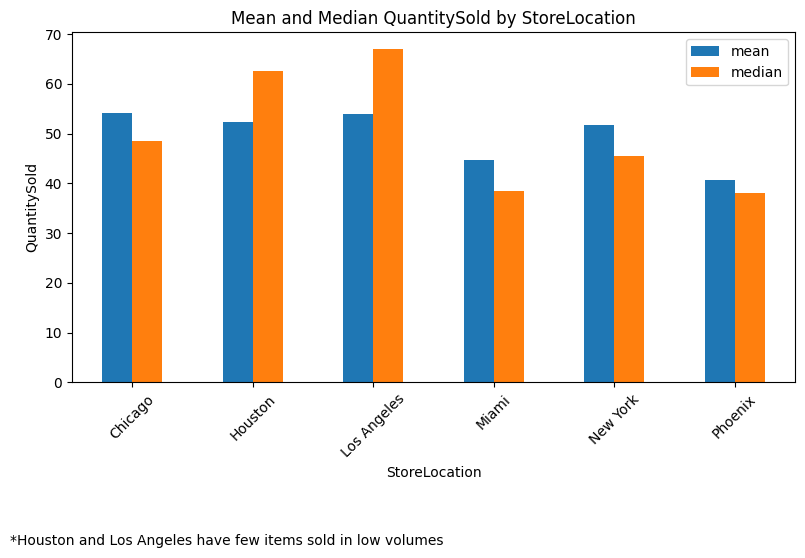

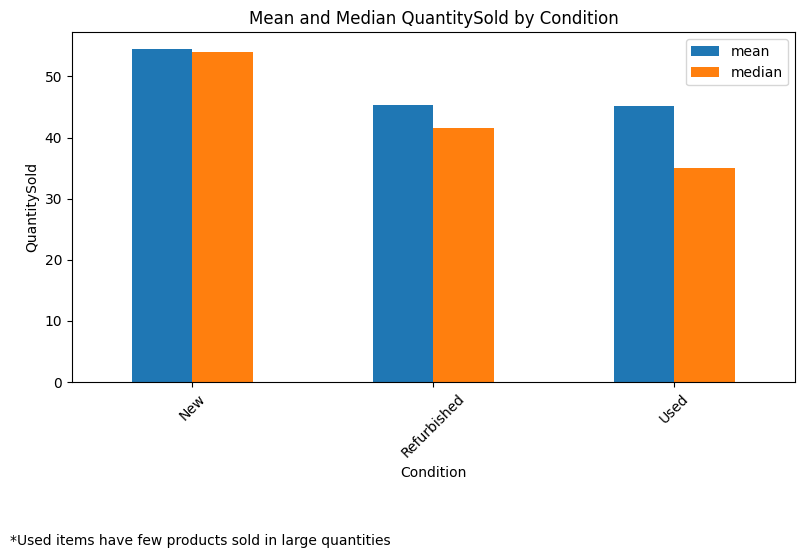

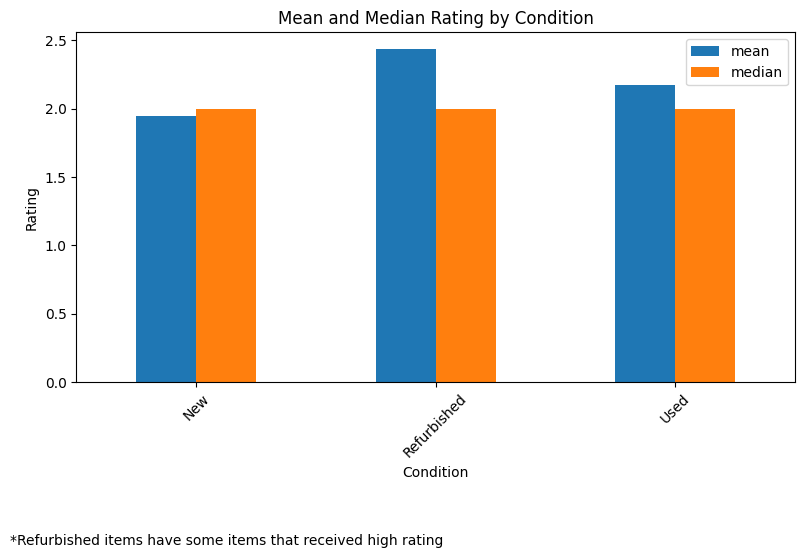

In [8]:
''' [7] EDA (Categorical Data) '''
# Nominal categories
# 1-2. Count, Visualize
categorical_cols = ['Brand', 'ProductType', 'StoreLocation']

for col in categorical_cols:
    print(f"{col} (Unique: {df[col].nunique()}):\n{df[col].value_counts()}\n")
    
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 3. Group (Barplot[C-N], Scatterplot[N-N])
# Brand-Price
brand_to_price=df.groupby('Brand')['Price'].agg(['mean','median'])
brand_to_price.plot(kind='bar', figsize=(8, 5))
plt.title('Mean and Median Price by Brand')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.figtext(
    0, -0.1,
    "*No insights",
    wrap=True,
    horizontalalignment='left',
    fontsize=10
)
plt.show()

# ProductType-Price
product_type_to_price=df.groupby('ProductType')['Price'].agg(['mean','median'])
product_type_to_price.plot(kind='bar', figsize=(8, 5))
plt.title('Mean and Median Price by ProductType')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.figtext(
    0, -0.1,
    "*Toys have few items with higher prices",
    wrap=True,
    horizontalalignment='left',
    fontsize=10
)
plt.show()

# Brand,ProductType-Price
brand_product_type_price=df.groupby(['Brand', 'ProductType'])['Price'].mean().unstack()
brand_product_type_price.plot(kind='bar', figsize=(10, 6))
plt.title('Average Price by Brand and Product Type')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.figtext(
    0, -0.1,
    "1. Extremely low average clothing price for Acme\n"
    "2. Umbrella doesn't sell furniture\n"
    "3. Acme doesn't sell books\n"
    "4. Toys have the highest price on average\n"
    "5. Food has the lowest deviation across all brands",
    wrap=True,
    horizontalalignment='left',
    fontsize=10
)
plt.show()

# ProductType-QuantitySold
product_type_to_quantity_sold=df.groupby('ProductType')['QuantitySold'].agg(['mean','median'])
product_type_to_quantity_sold.plot(kind='bar', figsize=(8, 5))
plt.title('Mean and Median QuantitySold by ProductType')
plt.ylabel('QuantitySold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.figtext(
    0, -0.1,
    "*Clothing, food, and toys have few items sold in large volumes",
    wrap=True,
    horizontalalignment='left',
    fontsize=10
)
plt.show()

# StoreLocation-QuantitySold
store_location_to_quantity_sold=df.groupby('StoreLocation')['QuantitySold'].agg(['mean','median'])
store_location_to_quantity_sold.plot(kind='bar', figsize=(8, 5))
plt.title('Mean and Median QuantitySold by StoreLocation')
plt.ylabel('QuantitySold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.figtext(
    0, -0.1,
    "*Houston and Los Angeles have few items sold in low volumes",
    wrap=True,
    horizontalalignment='left',
    fontsize=10
)
plt.show()

# Ordinal categories
# Condition-QuantitySold
condition_to_quantity_sold=df.groupby('Condition')['QuantitySold'].agg(['mean','median'])
condition_to_quantity_sold.plot(kind='bar', figsize=(8, 5))
plt.title('Mean and Median QuantitySold by Condition')
plt.ylabel('QuantitySold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.figtext(
    0, -0.1,
    "*Used items have few products sold in large quantities",
    wrap=True,
    horizontalalignment='left',
    fontsize=10
)
plt.show()

# Condition-Rating
condition_to_rating=df.groupby('Condition')['Rating'].agg(['mean','median'])
condition_to_rating.plot(kind='bar', figsize=(8, 5))
plt.title('Mean and Median Rating by Condition')
plt.ylabel('Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.figtext(
    0, -0.1,
    "*Refurbished items have some items that received high rating",
    wrap=True,
    horizontalalignment='left',
    fontsize=10
)
plt.show()

In [9]:
df=pd.get_dummies(df, columns=['Brand'], drop_first=True)
df=pd.get_dummies(df, columns=['ProductType'], drop_first=True)
df=pd.get_dummies(df, columns=['StoreLocation'], drop_first=True)
df['Condition']=df['Condition'].map({
    'Used': 0,
    'Refurbished': 1,
    'New': 2
})

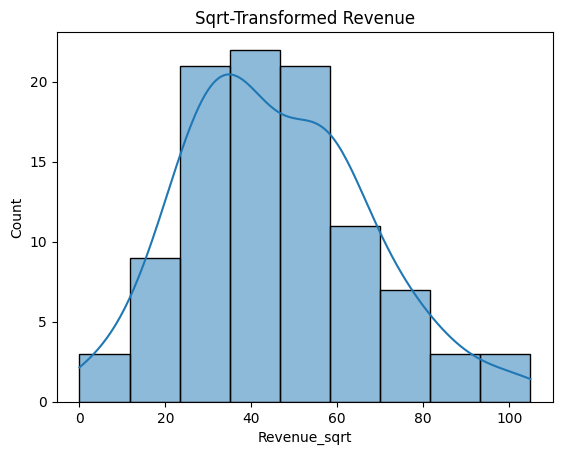

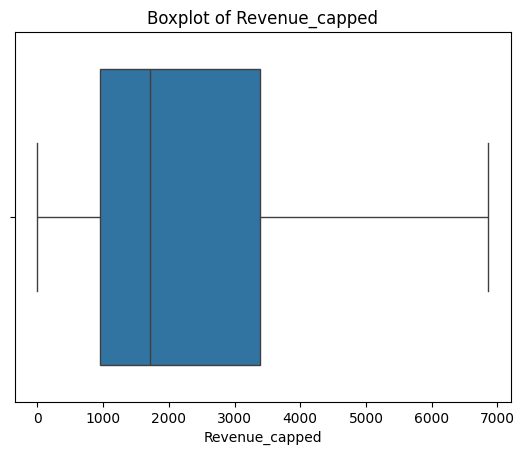

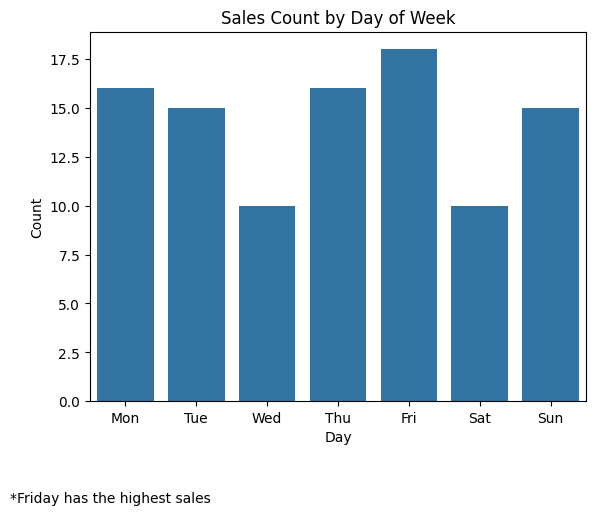

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Price                      100 non-null    float64       
 1   QuantitySold               100 non-null    int64         
 2   Condition                  100 non-null    int64         
 3   DateSold                   100 non-null    datetime64[ns]
 4   Rating                     100 non-null    int64         
 5   Price_capped               100 non-null    float64       
 6   Brand_Globex               100 non-null    bool          
 7   Brand_Hooli                100 non-null    bool          
 8   Brand_Initech              100 non-null    bool          
 9   Brand_Soylent              100 non-null    bool          
 10  Brand_Umbrella             100 non-null    bool          
 11  ProductType_Clothing       100 non-null    bool          
 12  ProductTy

In [10]:
''' [9] Feature Engineering '''
df['Revenue']=df['Price'] * df['QuantitySold']
df['DateSold']=pd.to_datetime(df['DateSold'])
df['MonthSold']=df['DateSold'].dt.month
df['DayOfWeekSold']=df['DateSold'].dt.weekday
df

df['Revenue_sqrt']=np.sqrt(df['Revenue'])

sns.histplot(df['Revenue_sqrt'], kde=True)
plt.title('Sqrt-Transformed Revenue')
plt.show()

upper_bound = df['Revenue'].quantile(0.95)
df['Revenue_capped'] = df['Revenue'].clip(upper=upper_bound)

sns.boxplot(x=df['Revenue_capped'])
plt.title('Boxplot of Revenue_capped')
plt.show()

day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
df['DayOfWeekName'] = df['DayOfWeekSold'].map(day_map)

sns.countplot(x='DayOfWeekName', data=df, order=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title('Sales Count by Day of Week')
plt.xlabel('Day')
plt.ylabel('Count')
plt.figtext(
    0, -0.1,
    "*Friday has the highest sales",
    wrap=True,
    horizontalalignment='left',
    fontsize=10
)
plt.show()

df.info()
df=df.drop(columns=['DayOfWeekName', 'DateSold'])

In [11]:
''' [10] Train Model '''
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Drop non-useful columns & target
df=df.drop(columns=['Price', 'Revenue', 'Revenue_capped'])

X=df.drop(columns=['QuantitySold'])
y=df['QuantitySold']

# Define numerical columns (excluding target)
numerical_cols=['Condition', 'Rating', 'Price_capped', 'MonthSold', 'Revenue_sqrt']

# Scale numerical features
scaler=StandardScaler()
df[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Train/test split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model=LinearRegression()
model.fit(X_train, y_train)

# Test model by making predictions
predictions=model.predict(X_test)

[ R² SCORE ]


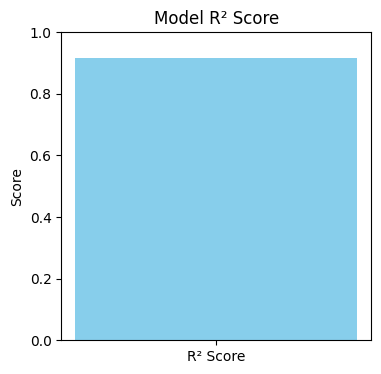

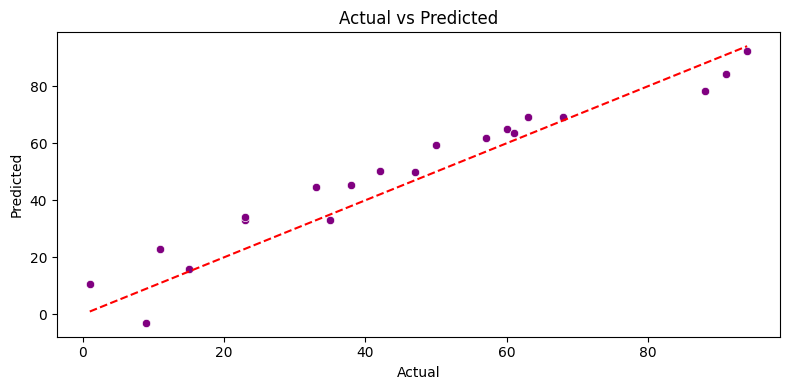

Mean Absolute Error: 6.72
Mean Squared Error: 59.47
Root Mean Squared Error: 7.71
R² Score: 0.92


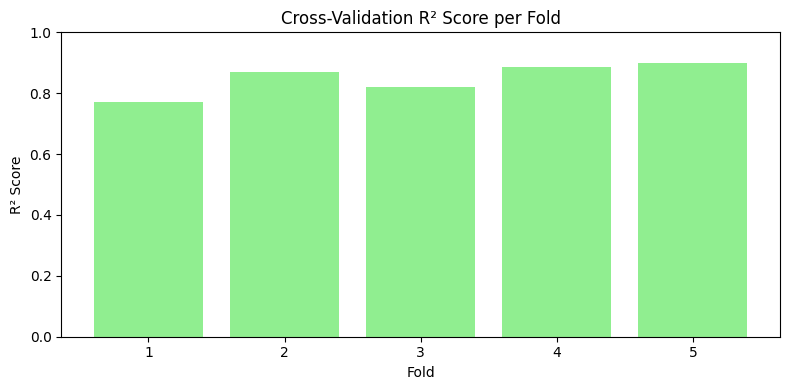

In [12]:
''' [11] Evaluate Model '''
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
r2 = r2_score(y_test, predictions)

# 1. R² Score - Bar Plot
print("[ R² SCORE ]")
plt.figure(figsize=(4, 4))
plt.bar(["R² Score"], [r2], color='skyblue')
plt.ylim(0, 1)
plt.title("Model R² Score")
plt.ylabel("Score")
plt.show()

# 2. Actual vs Predicted - Scatter Plot
plt.figure(figsize=(8, 4))
sns.scatterplot(x=y_test, y=predictions, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

# 3. Print Error Metrics
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# 4. Cross-Validation Scores - R²
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), scores, color='lightgreen')
plt.ylim(0, 1)
plt.title("Cross-Validation R² Score per Fold")
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.xticks(range(1, 6))
plt.tight_layout()
plt.show()

<Axes: >

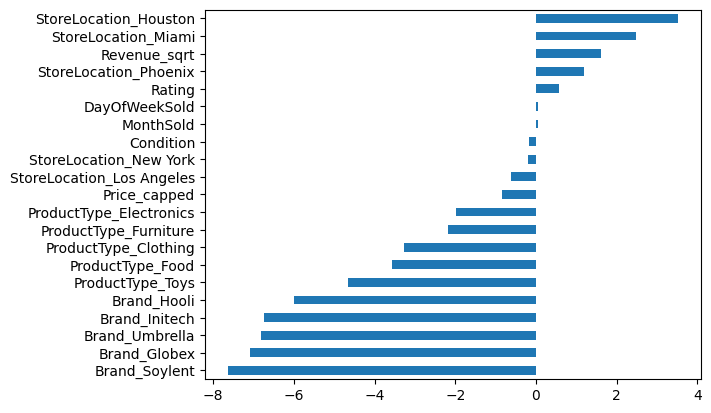

In [13]:
''' [12] Feature Importance/Model Interpretation '''
pd.Series(model.coef_, index=X.columns).sort_values().plot(kind='barh')

In [14]:
''' [13] Export Model & Results '''
import joblib

joblib.dump(model, 'ProductSales[QuantitySold].joblib')
df.to_csv('final_dataset.csv', index=False)